In [13]:
import os
import pandas as pd
from matplotlib import pyplot as plt
os.chdir(os.path.expanduser('~/wcEcoli/'))
import io
import numpy as np
from wholecell.io import tsv
from wholecell.utils.filepath import ROOT_PATH
import seaborn as sns

In [14]:
# Name the sequences to use:
current_sequence = "CLClimNE_complex_deg_test"
CLNE_sequence = "CLNE_clm"
branch_name = "pd-plots"
out_path = f"out/figures/{branch_name}/two_by_two_PC_comparisons/{current_sequence}__{CLNE_sequence}/"

if not os.path.exists(out_path):
    os.makedirs(out_path)

In [15]:
# function to match gene symbols to monomer ids
def get_gene_symbols_for_monomer_ids():
	"""
	Extracts the gene symbols for each monomer id in the model.
	Returns: a dictionary mapping monomer ids to gene symbols.
	Code adapted from convert_to_flat.py.
	"""
	RNAS_FILE = os.path.join(ROOT_PATH, 'reconstruction', 'ecoli',
								 'flat', 'rnas.tsv')
	with (io.open(RNAS_FILE, 'rb') as f):
		reader = tsv.reader(f, delimiter='\t')
		headers = next(reader)
		while headers[0].startswith('#'):
			headers = next(reader)

		# extract relevant information
		gene_symbol_index = headers.index('common_name')
		protein_id_index = headers.index('monomer_ids')
		monomer_ids_to_gene_symbols = {}
		for line in reader:
			gene_symbol = line[gene_symbol_index]
			protein_id = list(
				line[protein_id_index][2:-2].split('", "'))[0]
			monomer_ids_to_gene_symbols[protein_id] = gene_symbol

	return monomer_ids_to_gene_symbols

def get_common_name(protein_id):
    """
    Get the common name of a protein given its monomer id.
    Args:
        protein_id: the name of the monomer

    Returns:
        common_name: The common name of the protein.

    """
    # remove the compartment tag first if it exists:
    if '[' in protein_id:
        protein_id = protein_id[:-3]  # subtract the compartment
        common_name = get_gene_symbols_for_monomer_ids()[protein_id]
    else:
        common_name = get_gene_symbols_for_monomer_ids()[protein_id]
    return common_name

def r2_score_y_equals_x(y_true, y_pred):
    # Calculate the squared differences from the predicted line y=x
    residuals = y_true - y_pred
    ss_res = np.sum(residuals ** 2)  # Residual Sum of Squares

    # Calculate the total sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # Total Sum of Squares

    # Calculate R²
    r2 = 1 - (ss_res / ss_tot)

    return r2

# Prep the data

In [16]:
# Read in the 2020 model half life data:
CLNE_2020_HLs = f"out/{CLNE_sequence}/kb_plot_out/protein_half_lives_updated.tsv"
CLNE_2020_HLs = pd.read_csv(CLNE_2020_HLs, sep='\t')
CLNE_2020_HLs = CLNE_2020_HLs.rename(columns={"half_life(min)": "original_half_life"})
CLNE_2020_HLs = CLNE_2020_HLs.drop(columns={"degradation_rate(1/s)", "degradation_rate_source"})

# Read in the 2025 model half life data:
CLClimNE_2025_HLs = f"out/{current_sequence}/kb_plot_out/protein_half_lives_updated.tsv"
CLClimNE_2025_HLs = pd.read_csv(CLClimNE_2025_HLs, sep='\t')
CLClimNE_2025_HLs = CLClimNE_2025_HLs.rename(columns={"half_life(min)": "new_half_life"})
CLClimNE_2025_HLs = CLClimNE_2025_HLs.drop(columns={"degradation_rate(1/s)", "degradation_rate_source"})

# Merge the two together:
combined_df = pd.merge(CLClimNE_2025_HLs, CLNE_2020_HLs, on='monomer_id', how='inner')

# Add the common names to the dataframe:
combined_df['common_name'] = None
for index, row in combined_df.iterrows():
    common_name = get_common_name(row['monomer_id'])
    combined_df.at[index, 'common_name'] = common_name

# Add the counts data:
CLNE_new_name = "Log10 " + CLNE_sequence + " Average Monomer Counts"
CLClimNE_new_name = "Log10 " + current_sequence + " Average Monomer Counts"

# Read in the unfiltered data and remove the last three characters from each entry in the Monomer ID column:
CLNE_log_data = pd.read_csv(f'/Users/miagrahn/wcEcoli/out/{CLNE_sequence}/wildtype_000000/cohort_average_monomer_count_data/unfiltered_data/log_data/LogAvgProteinCounts_startGen_2.csv')
CLNE_log_data['Monomer ID'] = CLNE_log_data['Monomer ID'].str[:-3]
CLClimNE_log_data = pd.read_csv(
    f'out/{current_sequence}/wildtype_000000/cohort_average_monomer_count_data/unfiltered_data/log_data/LogAvgProteinCounts_startGen_2.csv')
CLClimNE_log_data['Monomer ID'] = CLClimNE_log_data['Monomer ID'].str[:-3]

# Merge the two dataframes:
CLNE_log_data = CLNE_log_data.rename(columns={"Log10 Average Monomer Counts": CLNE_new_name})
CLClimNE_log_data = CLClimNE_log_data.rename(columns={"Log10 Average Monomer Counts": CLClimNE_new_name})
CLNE_log_data = CLNE_log_data.set_index("Monomer ID")
CLClimNE_log_data = CLClimNE_log_data.set_index("Monomer ID")
CLNE_CLClimNE_log_data = CLNE_log_data.join(CLClimNE_log_data, on="Monomer ID", how="inner")
CLNE_CLClimNE_log_data = CLNE_CLClimNE_log_data.reset_index()
CLNE_CLClimNE_log_data = CLNE_CLClimNE_log_data.rename(columns={"Monomer ID": "monomer_id"})

# Merge the counts dataframe into combined_df:
combined_df = pd.merge(combined_df, CLNE_CLClimNE_log_data, on='monomer_id', how='inner')

# Find the differences between the 2020 half life and the 2025 half life:
combined_df['HL_difference'] = combined_df['new_half_life'] - combined_df['original_half_life']

# Make a new column that is the fold change in half life:
combined_df['HL_fold_change'] = combined_df['new_half_life'] / combined_df['original_half_life']

# Calcuate the log 2 fold change in half life:
combined_df['HL_log2_fold_change'] = np.log2(combined_df['HL_fold_change'])

# Read in the validation data and remove the last three characters from each entry in the Monomer ID column:
CLClimNE_log_validaiton_data = pd.read_csv(
    f'out/{current_sequence}/wildtype_000000/cohort_average_monomer_count_data/validation_data/log_data/Log10_Schmidt_Comparison_startGen_2.csv')
CLClimNE_log_validaiton_data['Monomer ID'] = CLClimNE_log_validaiton_data['Monomer ID'].str[:-3]

# Add the validation data to the combined_df:
combined_df['Log10 Validation Data Average Monomer Counts'] = None
for index, row in combined_df.iterrows():
    monomer_id = row['monomer_id']
    # Check if the monomer_id exists in the validation data
    if monomer_id in CLClimNE_log_validaiton_data['Monomer ID'].values:
        # Get the corresponding value from the validation data
        validation_value = CLClimNE_log_validaiton_data.loc[CLClimNE_log_validaiton_data['Monomer ID'] == monomer_id, 'Log10 Schmidt Validation Counts'].values[0]
        combined_df.at[index, 'Log10 Validation Data Average Monomer Counts'] = validation_value
    else:
        # If the monomer_id is not found, set it to None
        combined_df.at[index, 'Log10 Validation Data Average Monomer Counts'] = None

combined_df

,monomer_id,common_name_x,new_half_life,protease_assignment_x,ClpP_contribution_x,Lon_contribution_x,HslV_contribution_x,Unexplained_contribution_x,cistron_id_x,length_x,...,length_y,aa_counts_y,mw_y,common_name,Log10 CLNE_clm Average Monomer Counts,Log10 CLClimNE_complex_deg_test Average Monomer Counts,HL_difference,HL_fold_change,HL_log2_fold_change,Log10 Validation Data Average Monomer Counts
0,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-MONOMER,plsC,1137.765599,not applicable,0.000000,0.0,0.000000,0.000000,EG11377_RNA,245 [amino_acid],...,245 [amino_acid],[19 15 14 6 5 11 6 17 8 22 21 14 6 12 13 ...,27465.210999999996 [g/mol],plsC,2.120064,2.083522,537.765599,1.896276,0.923169,1.643453
1,1-PFK-MONOMER,fruK,1914.725052,not applicable,0.000000,0.0,0.000000,0.000000,EG10337_RNA,312 [amino_acid],...,312 [amino_acid],[30 18 11 17 4 19 11 29 4 15 30 12 8 13 13 ...,33749.587 [g/mol],fruK,1.997026,1.914576,1314.725052,3.191208,1.674103,1.755875
2,2-DEHYDROPANTOATE-REDUCT-MONOMER,panE,432.820802,not applicable,0.000000,0.0,0.000000,0.000000,G6239_RNA,303 [amino_acid],...,303 [amino_acid],[25 18 16 15 6 20 15 19 12 24 34 7 7 4 14 ...,33860.64 [g/mol],panE,2.411501,2.270511,-167.179198,0.721368,-0.471193,1.414973
3,2-ISOPROPYLMALATESYN-MONOMER,leuA,424.427352,not applicable,0.000000,0.0,0.000000,0.000000,EG11226_RNA,523 [amino_acid],...,523 [amino_acid],[61 27 30 29 6 41 22 35 15 39 36 27 13 15 12 ...,57281.702 [g/mol],leuA,3.689613,3.293162,-175.572648,0.707379,-0.499445,3.43329
4,2-OCTAPRENYL-METHOXY-BENZOQ-METH-MONOMER,ubiE,1416.687662,not applicable,0.000000,0.0,0.000000,0.000000,EG11473_RNA,251 [amino_acid],...,251 [amino_acid],[20 15 9 19 2 11 7 19 7 11 23 16 10 13 7 ...,28074.177 [g/mol],ubiE,2.619993,2.575855,816.687662,2.361146,1.239487,2.968483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,YTFR-MONOMER,ytfR,1914.725052,not applicable,0.000000,0.0,0.000000,0.000000,EG12518_RNA,500 [amino_acid],...,500 [amino_acid],[43 39 13 24 5 37 26 40 7 40 63 21 11 18 21 ...,55258.920999999995 [g/mol],ytfR,1.331255,1.798234,1314.725052,3.191208,1.674103,0.0
4306,YTFT-MONOMER,ytfT,1914.725052,not applicable,0.000000,0.0,0.000000,0.000000,EG12520_RNA,341 [amino_acid],...,341 [amino_acid],[39 14 11 10 2 3 11 35 1 34 53 7 12 13 15 ...,35666.971999999994 [g/mol],ytfT,1.373532,1.777772,1314.725052,3.191208,1.674103,None
4307,ZNUA-MONOMER,znuA,1914.725052,not applicable,0.000000,0.0,0.000000,0.000000,G7017_RNA,310 [amino_acid],...,310 [amino_acid],[36 9 7 20 2 20 16 22 13 9 34 20 7 13 16 ...,33766.248999999996 [g/mol],znuA,2.728022,2.808584,1314.725052,3.191208,1.674103,2.638489
4308,ZNUB-MONOMER,znuB,600.000000,not applicable,0.000000,0.0,0.000000,0.000000,EG12368_RNA,261 [amino_acid],...,261 [amino_acid],[33 9 3 9 2 4 5 21 2 18 47 6 13 12 10 ...,27730.621999999996 [g/mol],znuB,1.846681,1.749239,0.000000,1.000000,0.000000,None


# Plot with titles

Filtered to 2141 proteins with validation data
greater than 4: 4
between 4 and 0: 1658
exactly 0: 152
between 0 and -4.6: 316
less than -4.6: 11


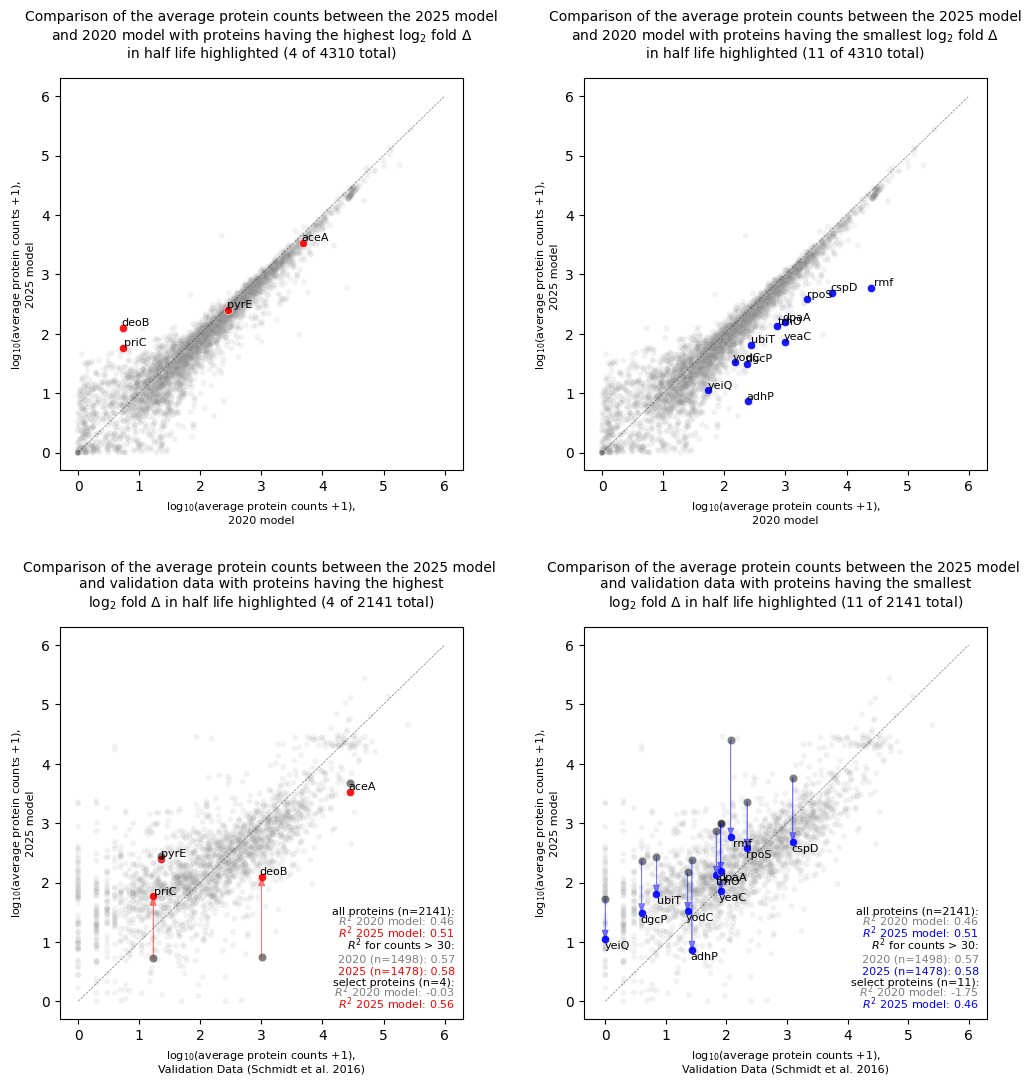

In [22]:
# FUNCTIONS
def obtain_data(df, column, upper, middle, lower):
    # Find all of the half lives that are greater than the upper limit:
    df_above_upper = df[df[column] > upper] #
    df_above_upper = df_above_upper.copy()
    df_above_upper["sort_color"] = "red"
    df_above_upper["column_width"] = "1"
    words_u = f'greater than {upper}: {df_above_upper.shape[0]}'
    print(words_u)

    # find all the half lives between 800 and 0:
    df_upper_to_zero = df[(df[column] <= upper) & (df[column] > middle)] #
    df_upper_to_zero = df_upper_to_zero.copy()
    df_upper_to_zero["sort_color"] = "orange"
    df_upper_to_zero["column_width"] = "4"
    words_u2m = f'between {upper} and {middle}: {df_upper_to_zero.shape[0]}'
    print(words_u2m)

    df_middle = df[df[column] == middle ] #
    df_middle = df_middle.copy()
    df_middle["sort_color"] = "green"
    df_middle["column_width"] = "4"
    words_m = f'exactly {middle}: {df_middle.shape[0]}'
    print(words_m)

    # find all half lives between 600 and 200:
    df_0_to_lower = df[(df[column] < middle) & (df[column] >= lower)] #
    df_0_to_lower = df_0_to_lower.copy()
    df_0_to_lower["sort_color"] = "lightblue"
    df_0_to_lower["column_width"] = "4"
    words_m2l = f'between {middle} and {lower}: {df_0_to_lower.shape[0]}'
    print(words_m2l)

    # find all the half lives between 200 and 0:
    df_lower = df[(df[column] < lower)] #
    df_lower = df_lower.copy()
    df_lower["sort_color"] = "blue"
    df_lower["column_width"] = "1"
    words_l = f'less than {lower}: {df_lower.shape[0]}'
    print(words_l)

    return(df_above_upper, df_upper_to_zero, df_middle, df_0_to_lower, df_lower, words_u, words_u2m, words_m, words_m2l, words_l)

# make the validation plot:
def make_counts_comparison_with_upper_HL_change_data(row, col, whole_df, interest_df):
    # define the axes:
    ax = axes[row, col]

    # plot all of the proteins
    sns.scatterplot(data=whole_df, x=whole_df[CLNE_new_name], y=whole_df[CLClimNE_new_name], color='grey', size=0.1, alpha=0.1, ax=ax, )

    # plot the proteins of interest:
    sns.scatterplot(data=interest_df, x=interest_df[CLNE_new_name], y=interest_df[CLClimNE_new_name], color='red', alpha=0.9, ax=ax, )
    ax.plot([0, 6], [0, 6], color='black', linestyle='--', linewidth=.5, alpha=0.5)

    # plot the common name of the proteins of interest:
    for i, name in enumerate(interest_df['common_name'].unique()):
        # get the index of the protein:
        index = interest_df[interest_df['common_name'] == name].index[0]
        # get the x and y values:
        x = interest_df[CLNE_new_name][index]
        y = interest_df[CLClimNE_new_name][index]
        # plot the common name:
        ax.text(x +.2, y, name, ha='center', va='bottom', fontsize=8, rotation=0, )

    # Plot specs:
    ax.set_title(f'Comparison of the average protein counts between the 2025 model\nand 2020 model with proteins having the highest log$_{{2}}$ fold $\\Delta$\nin half life highlighted ({interest_df.shape[0]} of {whole_df.shape[0]} total)', fontsize=10, pad=15, )
    ax.set_xlabel(f'log$_{{10}}$(average protein counts +1),\n2020 model', fontsize=8, color="black", )
    ax.set_ylabel(f'log$_{{10}}$(average protein counts +1),\n2025 model', fontsize=8, color="black", )
    ax.legend()
    ax.get_legend().set_visible(False)


def make_counts_comparison_with_lower_HL_change_data(row, col, whole_df, interest_df):
    # define the axes:
    ax = axes[row, col]

    # plot all of the proteins
    sns.scatterplot(data=whole_df, x=whole_df[CLNE_new_name], y=whole_df[CLClimNE_new_name], color='grey', size=.1, alpha=0.1, ax=ax)

    # plot the proteins of interest:
    sns.scatterplot(data=interest_df, x=interest_df[CLNE_new_name], y=interest_df[CLClimNE_new_name], color='blue', alpha=0.9, ax=ax)
    ax.plot([0, 6], [0, 6], color='black', linestyle='--', linewidth=.5, alpha=0.5)


    # plot the common name of the proteins of interest:
    for i, name in enumerate(interest_df['common_name'].unique()):
        # get the index of the protein:
        index = interest_df[interest_df['common_name'] == name].index[0]
        # get the x and y values:
        x = interest_df[CLNE_new_name][index]
        y = interest_df[CLClimNE_new_name][index]
        # plot the common name:
        ax.text(x+.2, y, name, ha='center', va='bottom', fontsize=8, rotation=0, )

    # Plot specs:
    ax.set_title(f'Comparison of the average protein counts between the 2025 model\nand 2020 model with proteins having the smallest log$_{{2}}$ fold $\\Delta$\nin half life highlighted ({interest_df.shape[0]} of {whole_df.shape[0]} total)', fontsize=10, pad=15, )
    ax.set_xlabel(f'log$_{{10}}$(average protein counts +1),\n2020 model', fontsize=8, color="black", )
    ax.set_ylabel(f'log$_{{10}}$(average protein counts +1),\n2025 model ', fontsize=8, color="black", )
    ax.legend()
    ax.get_legend().set_visible(False)

def make_counts_comparison_with_upper_HL_change_validation_data(row, col, whole_df, interest_df):
    # define the axes:
    ax = axes[row, col]

    # clean up the data:
    x_col = 'Log10 Validation Data Average Monomer Counts'
    y_col = CLClimNE_new_name
    y_col2 = CLNE_new_name

    # Remove proteins that have "None" in their y_col (no validation value):
    whole_df_to_plot = whole_df[whole_df[x_col].notna()]
    interest_df_to_plot = interest_df[interest_df[x_col].notna()]

    # plot all of the proteins
    sns.scatterplot(data=whole_df_to_plot, x=whole_df_to_plot[x_col], y=whole_df_to_plot[y_col], color='grey', size=.1, alpha=0.1, ax=ax,)

    # plot the proteins of interest:
    sns.scatterplot(data=interest_df_to_plot, x=interest_df_to_plot[x_col], y=interest_df_to_plot[y_col], color='red', alpha=0.9, ax=ax)
    sns.scatterplot(data=interest_df_to_plot, x=interest_df_to_plot[x_col], y=interest_df_to_plot[y_col2], color='black', alpha=0.5, ax=ax)

    # add a y=x dotted line:
    ax.plot([0, 6], [0, 6], color='black', linestyle='--', linewidth=.5, alpha=0.5)

    # calculate the coefficent of determination for all proteins (y_true, y_pred are inputs, where here, y_true is the x values (validation data) and y_pred is the model data):
    r2_2025_all = r2_score_y_equals_x(whole_df_to_plot[x_col], whole_df_to_plot[y_col])
    r2_2020_all = r2_score_y_equals_x(whole_df_to_plot[x_col], whole_df_to_plot[y_col2])

    # calculate the R2 for counts above 30:
    filtered_df_2025 = whole_df_to_plot[(whole_df_to_plot[x_col] > np.log10(30+1)) & (whole_df_to_plot[y_col] > np.log10(30+1))]
    filtered_df_2020 = whole_df_to_plot[(whole_df_to_plot[x_col] > np.log10(30+1)) & (whole_df_to_plot[y_col2] > np.log10(30+1))]
    r2_2025_all_above_30 = r2_score_y_equals_x(filtered_df_2025[x_col], filtered_df_2025[y_col])
    r2_2020_all_above_30 = r2_score_y_equals_x(filtered_df_2020[x_col], filtered_df_2020[y_col2])

    # calcuate the R^2 for the 2020 vs 2025 model
    r2_2025 = r2_score_y_equals_x(interest_df_to_plot[x_col], interest_df_to_plot[y_col])
    r2_2020 = r2_score_y_equals_x(interest_df_to_plot[x_col], interest_df_to_plot[y_col2])

    ax.text(0.98, 0.26, f"all proteins (n={whole_df_to_plot.shape[0]}):", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.23, f"$R^2$ 2020 model: {r2_2020_all:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')
    ax.text(0.98, 0.20, f"$R^2$ 2025 model: {r2_2025_all:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='red')
    ax.text(0.98, 0.17, f"$R^2$ for counts > 30:", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.14, f"2020 (n={filtered_df_2020.shape[0]}): {r2_2020_all_above_30:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')
    ax.text(0.98, 0.11, f"2025 (n={filtered_df_2025.shape[0]}): {r2_2025_all_above_30:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='red')
    ax.text(0.98, 0.08, f"select proteins (n={len(interest_df_to_plot[x_col])}):", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.02, f"$R^2$ 2025 model: {r2_2025:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='red')
    ax.text(0.98, 0.05, f"$R^2$ 2020 model: {r2_2020:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')

    # plot the common name of the proteins of interest:
    for i, name in enumerate(interest_df_to_plot['common_name'].unique()):
        # get the index of the protein:
        index = interest_df_to_plot[interest_df_to_plot['common_name'] == name].index[0]
        # get the x and y values:
        x = interest_df_to_plot[x_col][index]
        y = interest_df_to_plot[y_col][index]
        # plot the common name:
        ax.text(x+.2, y, name, ha='center', va='bottom', fontsize=8, rotation=0, )

        # also make a line between the two:
        y2 = interest_df_to_plot[y_col2][index]
        difference = y - y2
        if abs(difference) > 0.2:
            dx = x-x
            dy = y - y2
            ax.arrow(x, y2, dx, dy, color='red', linewidth=.5, alpha=0.5, head_width=0.1, head_length=0.15, length_includes_head=True)

    # Plot specs:
    ax.set_title(f'Comparison of the average protein counts between the 2025 model \nand validation data with proteins having the highest\nlog$_{{2}}$ fold $\\Delta$ in half life highlighted ({len(interest_df_to_plot[x_col])} of {whole_df_to_plot.shape[0]} total)', fontsize=10, pad=15, )
    ax.set_xlabel(f'log$_{{10}}$(average protein counts +1),\nValidation Data (Schmidt et al. 2016)', fontsize=8, color="black", )
    ax.set_ylabel(f'log$_{{10}}$(average protein counts +1),\n2025 model', fontsize=8, color="black", )
    ax.legend()
    ax.get_legend().set_visible(False)


# now make a plot for the validation comparison:
def make_counts_comparison_with_lower_HL_change_validation_data(row, col, whole_df, interest_df):
    # define the axes:
    ax = axes[row, col]

    # clean up the data:
    x_col = 'Log10 Validation Data Average Monomer Counts'
    y_col = CLClimNE_new_name
    y_col2 = CLNE_new_name

    # remove proteins that have "None" in their y_col:
    whole_df_to_plot = whole_df[whole_df[x_col].notna()]
    interest_df_to_plot = interest_df[interest_df[x_col].notna()]

    # plot all the proteins
    sns.scatterplot(data=whole_df_to_plot, x=whole_df_to_plot[x_col], y=whole_df_to_plot[y_col], color='grey', size=.1, alpha=0.1, ax=ax,)

    # plot the proteins of interest:
    sns.scatterplot(data=interest_df_to_plot, x=interest_df_to_plot[x_col], y=interest_df_to_plot[y_col], color='blue', alpha=0.9, ax=ax,)
    sns.scatterplot(data=interest_df_to_plot, x=interest_df_to_plot[x_col], y=interest_df_to_plot[y_col2], color='black', alpha=0.5, ax=ax,)

    # add a y=x dotted line:
    ax.plot([0, 6], [0, 6], color='black', linestyle='--', linewidth=.5, alpha=0.5)

    # plot the common name of the proteins of interest:
    for i, name in enumerate(interest_df_to_plot['common_name'].unique()):
        # get the index of the protein:
        index = interest_df_to_plot[interest_df_to_plot['common_name'] == name].index[0]
        # get the x and y values:
        x = interest_df_to_plot[x_col][index]
        y = interest_df_to_plot[y_col][index]
        # plot the common name:
        ax.text(x+.2, y-.2, name, ha='center', va='bottom', fontsize=8, rotation=0, )

        # also make a line between the two:
        y2 = interest_df_to_plot[y_col2][index]
        difference = y - y2
        if abs(difference) > 0.2:
            dx = x-x
            dy = y - y2
            ax.arrow(x, y2, dx, dy, color='blue', linewidth=.5, alpha=0.5, head_width=0.1, head_length=0.15, length_includes_head=True)

    # calculate the coefficent of determination for all proteins:
    r2_2025_all = r2_score_y_equals_x(whole_df_to_plot[x_col], whole_df_to_plot[y_col])
    r2_2020_all = r2_score_y_equals_x(whole_df_to_plot[x_col], whole_df_to_plot[y_col2])

    # calculate the R2 for counts above 30:
    filtered_df_2025 = whole_df_to_plot[(whole_df_to_plot[x_col] > np.log10(30+1)) & (whole_df_to_plot[y_col] > np.log10(30+1))]
    filtered_df_2020 = whole_df_to_plot[(whole_df_to_plot[x_col] > np.log10(30+1)) & (whole_df_to_plot[y_col2] > np.log10(30+1))]
    r2_2025_all_above_30 = r2_score_y_equals_x(filtered_df_2025[x_col], filtered_df_2025[y_col])
    r2_2020_all_above_30 = r2_score_y_equals_x(filtered_df_2020[x_col], filtered_df_2020[y_col2])

    # calcuate the R^2 for the 2020 vs 2025 model
    r2_2025 = r2_score_y_equals_x(interest_df_to_plot[x_col], interest_df_to_plot[y_col])
    r2_2020 = r2_score_y_equals_x(interest_df_to_plot[x_col], interest_df_to_plot[y_col2])

    ax.text(0.98, 0.26, f"all proteins (n={whole_df_to_plot.shape[0]}):", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.23, f"$R^2$ 2020 model: {r2_2020_all:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')
    ax.text(0.98, 0.20, f"$R^2$ 2025 model: {r2_2025_all:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='blue')
    ax.text(0.98, 0.17, f"$R^2$ for counts > 30:", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.14, f"2020 (n={filtered_df_2020.shape[0]}): {r2_2020_all_above_30:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')
    ax.text(0.98, 0.11, f"2025 (n={filtered_df_2025.shape[0]}): {r2_2025_all_above_30:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='blue')
    ax.text(0.98, 0.08, f"select proteins (n={len(interest_df_to_plot[x_col])}):", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='black')
    ax.text(0.98, 0.02, f"$R^2$ 2025 model: {r2_2025:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='blue')
    ax.text(0.98, 0.05, f"$R^2$ 2020 model: {r2_2020:.2f}", transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='grey')

    # Plot specs:
    ax.set_title(f'Comparison of the average protein counts between the 2025 model \nand validation data with proteins having the smallest\nlog$_{{2}}$ fold $\\Delta$ in half life highlighted ({len(interest_df_to_plot[x_col])} of {whole_df_to_plot.shape[0]} total)', fontsize=10, pad=15, )
    ax.set_xlabel(f'log$_{{10}}$(average protein counts +1),\nValidation Data (Schmidt et al. 2016)', fontsize=8, color="black", )
    ax.set_ylabel(f'log$_{{10}}$(average protein counts +1),\n2025 model', fontsize=8, color="black", )
    legend_labels = [f"proteins with the largest -$\\Delta$\nin half life in the 2025 model (n={interest_df_to_plot.shape[0]})",  f"2020 model value"]
    ax.legend()
    ax.get_legend().set_visible(False)


# USER INPUTS:

# Define bounds for the fold changes in half lives:
HL_upper = 4
HL_middle = 0
HL_lower = -4.6

# Plot file title:
specific_title = f"counts_validation_matrix_HL_bounds[{HL_lower},{HL_middle},{HL_upper}]_{current_sequence}_{CLNE_sequence}_no_nulls.png"
out_pth_validation_matrix = out_path + specific_title

# Copy the dataframe to use:
df = combined_df.copy()

# Filter to only use proteins that we have validation data for:
df = df[df['Log10 Validation Data Average Monomer Counts'].notna()]
print(f"Filtered to {df.shape[0]} proteins with validation data")

# Define the column to use:
column = 'HL_log2_fold_change'
validaiton_column = 'Log10 Validation Data Average Monomer Counts'

# END USER INPUTS

# Obtain the data to use based on the upper and lower limits:
df_above_upper, df_upper_to_zero, df_middle, df_zero_to_lower, df_lower, words_u, words_u2m, words_m, words_m2l, words_l = obtain_data(df, column, HL_upper, HL_middle, HL_lower)

# MAKE THE PLOT
# reference: https://sharkcoder.com/data-visualization/mpl-bidirectional
fig, axes = plt.subplots(figsize=(10,10),  nrows=2, ncols=2, gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 1]})
fig.tight_layout()

# plot the plots
make_counts_comparison_with_upper_HL_change_data(0, 0, combined_df, df_above_upper)
make_counts_comparison_with_lower_HL_change_data(0, 1, combined_df, df_lower)
make_counts_comparison_with_upper_HL_change_validation_data(1, 0, combined_df, df_above_upper)
make_counts_comparison_with_lower_HL_change_validation_data(1, 1, combined_df, df_lower)

fig.subplots_adjust(wspace=0.3, hspace=0.4)

# save the figure:
out_pth = os.path.expanduser(out_pth_validation_matrix)
output_dir = os.path.dirname(out_pth)
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it does not exist
plt.savefig(out_pth, dpi=300, bbox_inches='tight')
